#2.0 Machine learning for linear regression

In [3]:
import pandas as pd
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

#2.1 Download dataset

In [4]:

data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv'
!wget $data

--2026-10-05 19:42:35--  https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 

200 OK
Length: 1475504 (1.4M) [text/plain]
Saving to: ‘data.csv.1’

data.csv.1          100%[===================>]   1.41M  --.-KB/s    in 0.006s  

2026-10-05 19:42:35 (226 MB/s) - ‘data.csv.1’ saved [1475504/1475504]



#2.2 Data preparation

In [5]:

car_df = pd.read_csv('data.csv')
car_df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [6]:
car_df.columns.str.lower()

Index(['make', 'model', 'year', 'engine fuel type', 'engine hp',
       'engine cylinders', 'transmission type', 'driven_wheels',
       'number of doors', 'market category', 'vehicle size', 'vehicle style',
       'highway mpg', 'city mpg', 'popularity', 'msrp'],
      dtype='str')

In [7]:
car_df.columns.str.lower().str.replace(' ', '_')

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity', 'msrp'],
      dtype='str')

In [8]:
car_df.columns = car_df.columns.str.lower().str.replace(' ', '_')

In [9]:
car_df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [10]:
car_df.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [11]:
strings= list(car_df.dtypes[car_df.dtypes == 'object'].index)
strings

[]

In [12]:
car_df.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [13]:
strings = list(car_df.dtypes[car_df.dtypes == 'object'].index)
strings

[]

In [14]:
car_df

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,46120
11910,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,56670
11911,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50620
11912,Acura,ZDX,2013,premium unleaded (recommended),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50920


In [15]:
strings = list(car_df.dtypes[car_df.dtypes == 'string'].index)
strings

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [16]:
car_df.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity', 'msrp'],
      dtype='str')

In [17]:
for col in strings:
    car_df[col] = car_df[col].str.lower().str.replace(' ', '_')

In [18]:
car_df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


In [19]:
# Now let's do EDA (Exploratory Data Analysis) and see what we have in the dataset.
for col in car_df.columns:
    print(f'Column: {col}')
    print(car_df[col].unique()[:5])  # Print first 5 unique values
    print(car_df[col].nunique())
    print()

Column: make
<StringArray>
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']
Length: 5, dtype: str
48

Column: model
<StringArray>
['1_series_m', '1_series', '100', '124_spider', '190-class']
Length: 5, dtype: str
914

Column: year
[2011 2012 2013 1992 1993]
28

Column: engine_fuel_type
<StringArray>
[   'premium_unleaded_(required)',               'regular_unleaded',
 'premium_unleaded_(recommended)',       'flex-fuel_(unleaded/e85)',
                         'diesel']
Length: 5, dtype: str
10

Column: engine_hp
[335. 300. 230. 320. 172.]
356

Column: engine_cylinders
[ 6.  4.  5.  8. 12.]
9

Column: transmission_type
<StringArray>
['manual', 'automatic', 'automated_manual', 'direct_drive', 'unknown']
Length: 5, dtype: str
5

Column: driven_wheels
<StringArray>
['rear_wheel_drive', 'front_wheel_drive', 'all_wheel_drive',
 'four_wheel_drive']
Length: 4, dtype: str
4

Column: number_of_doors
[ 2.  4.  3. nan]
3

Column: market_category
<StringArray>
['factory_tuner,luxury,high-perfor

#2.3 Exploratory data analysis

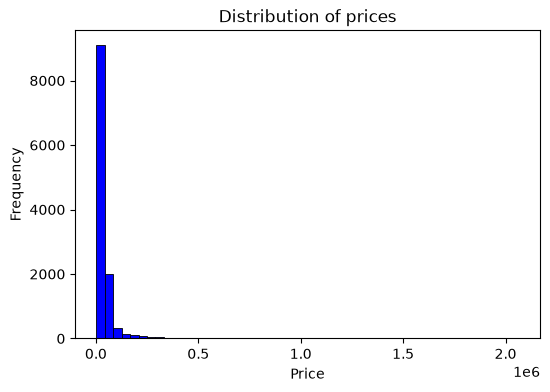

In [20]:
# Create a histogram of the 'msrp' column to visualize the distribution of car prices.
plt.figure(figsize=(6, 4))

sns.histplot(car_df.msrp, bins=50, color='blue', alpha=1)
plt.ylabel('Frequency')
plt.xlabel('Price')
plt.title('Distribution of prices')

plt.show()

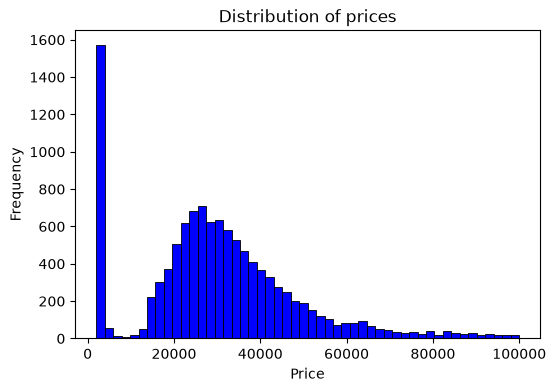

In [21]:
plt.figure(figsize=(6, 4))

sns.histplot(car_df.msrp[car_df.msrp < 100000], bins=50, color='blue', alpha=1)
plt.ylabel('Frequency')
plt.xlabel('Price')
plt.title('Distribution of prices')

plt.show()

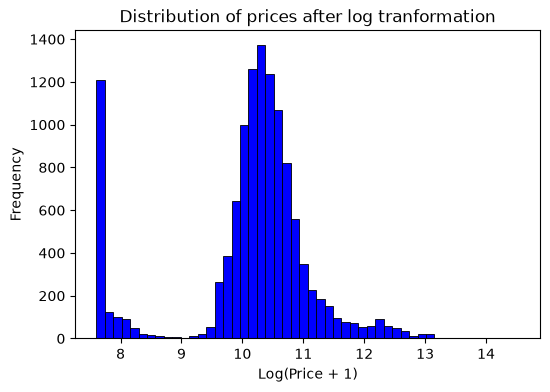

In [22]:
#Remove outliers and apply log transformation to the 'msrp' column to visualize the distribution of car prices after transformation.
log_price = np.log1p(car_df.msrp)

plt.figure(figsize=(6, 4))

sns.histplot(log_price, bins=50, color='blue', alpha=1)
plt.ylabel('Frequency')
plt.xlabel('Log(Price + 1)')
plt.title('Distribution of prices after log tranformation')

plt.show()

In [23]:
#Count missing values in each column of the dataset to identify any potential data quality issues.
car_df.isnull().sum()
#Retrive the median value of engine_hp column to fill missing values in the dataset.
engine_hp_median = car_df.engine_hp.median()
engine_hp_median


np.float64(227.0)

#2.4 Setting validation framework

In [24]:
n= len(car_df)
n_val = int(n*0.2)
n_test = int(n*0.2)

n_train = n - n_val - n_test
n, n_val, n_test, n_train
car_df.iloc[:10]

df_val = car_df.iloc[:n_val]
df_test = car_df.iloc[n_val:n_val+n_test]
df_train = car_df.iloc[n_val+n_test:]

idx = np.arange(n)
np.random.shuffle(idx)

train_idx = idx[:n_train]
df_train = car_df.iloc[idx[:n_train]]
df_val = car_df.iloc[idx[n_train:n_train+n_val]]
df_test = car_df.iloc[idx[n_train+n_val:]]

np.random.seed(2)
idx = np.arange(n)
np.random.shuffle(idx)

len(df_train), len(df_val), len(df_test)

df_train
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,ford,taurus,2016,premium_unleaded_(recommended),365.0,6.0,automatic,all_wheel_drive,4.0,"factory_tuner,high-performance",large,sedan,24,16,5657,40275
1,honda,ridgeline,2017,regular_unleaded,280.0,6.0,automatic,all_wheel_drive,4.0,NaN,large,crew_cab_pickup,25,18,2202,41370
2,land_rover,range_rover,2016,diesel,254.0,6.0,automatic,four_wheel_drive,4.0,"diesel,luxury",large,4dr_suv,29,22,258,93450
3,subaru,brz,2017,premium_unleaded_(required),200.0,4.0,automatic,rear_wheel_drive,2.0,performance,compact,coupe,33,24,640,28745
4,chevrolet,s-10_blazer,1994,regular_unleaded,165.0,6.0,manual,rear_wheel_drive,4.0,NaN,midsize,4dr_suv,20,15,1385,2000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7145,mercedes-benz,300-class,1991,regular_unleaded,177.0,6.0,automatic,rear_wheel_drive,4.0,luxury,large,sedan,19,15,617,2232
7146,bmw,3_series_gran_turismo,2015,premium_unleaded_(required),240.0,4.0,automatic,all_wheel_drive,4.0,"hatchback,luxury",midsize,4dr_hatchback,33,22,3916,41850
7147,subaru,impreza_wrx,2014,premium_unleaded_(required),305.0,4.0,manual,all_wheel_drive,4.0,"factory_tuner,high-performance",compact,sedan,23,17,640,34495
7148,kia,optima,2014,regular_unleaded,192.0,4.0,automatic,front_wheel_drive,4.0,NaN,midsize,sedan,34,23,1720,23950


In [25]:
y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)

In [26]:
del df_train['msrp']
del df_val['msrp']
del df_test['msrp']

#2.5 Linear regression simple

In [27]:
xi = [453, 11, 86]
w0 = 7.17
w = [0.01, 0.04, 0.002]
def linear_regression(xi):
    n = len(xi)

    pred = w0

    for j in range(n):
        pred = pred + w[j] * xi[j]

    return pred

linear_regression(xi)
np.expm1(12.312)
np.log1p(222347.2221101062)

np.float64(12.312)

#2.6 Linear regression vector form

In [28]:
def dot(xi, w):
    n = len(xi)

    res = 0.0

    for j in range(n):
        res = res + xi[j] * w[j]

    return res

def linear_regression(xi):
    pred = w0 + dot(xi, w)

    return pred


w_new = [w0] + w
def linear_regression(xi):
    xi = [1] + xi
    return dot(xi, w_new)

linear_regression(xi)
x1  = [1, 148, 24, 1385]
x2  = [1, 132, 25, 2031]
x10 = [1, 453, 11, 86]

X = [x1, x2, x10]
X = np.array(X)
X
w0 = 7.17
w = [0.01, 0.04, 0.002]
w_new = [w0] + w

def linear_regression(X):
    return X.dot(w_new)

linear_regression(X)

array([12.38 , 13.552, 12.312])

#2.7 Training linear regression: normal equatio

In [29]:
X = [
    [148, 24, 1385],
    [132, 25, 2031],
    [453, 11, 86],
    [158, 24, 185],
    [172, 25, 201],
    [413, 11, 86],
    [38,  54, 185],
    [142, 25, 431],
    [453, 31, 86],
]
X = np.array(X)
XTX = X.T.dot(X)
XTX_inv = np.linalg.inv(XTX)
XTX.dot(XTX_inv).round(1)

y = [100, 200, 150, 250, 100, 200, 150, 250, 120]
w_full = XTX_inv.dot(X.T).dot(y)
ones = np.ones(X.shape[0])
X = np.column_stack([ones, X])
XTX = X.T.dot(X)
XTX_inv = np.linalg.inv(XTX)
w_full = XTX_inv.dot(X.T).dot(y)
w0 = w_full[0]
w0

def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

#2.8 Baseline model for car price prediction project

In [30]:
df_train.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity'],
      dtype='str')

In [31]:
base = ['engine_hp', 'engine_cylinders', 'highway_mpg','city_mpg', 'popularity']
X_train = df_train[base].values

<Axes: ylabel='Count'>

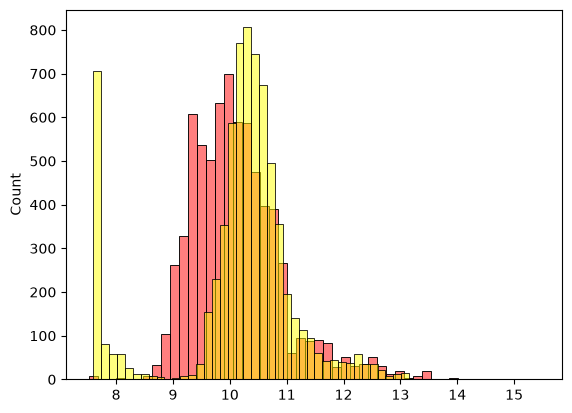

In [32]:
w0, w = train_linear_regression(X_train, y_train)
w0, w
df_train[base].isnull().sum()
X_train = df_train[base].fillna(0).values

w0, w = train_linear_regression(X_train, y_train)
w0, w
y_pred = w0 + X_train.dot(w)

sns.histplot(y_pred, color='red', alpha=0.5, bins=50)
sns.histplot(y_train, color='yellow', alpha=0.5, bins=50)

#2.9 Root Mean Squared Error (RMSE)


In [33]:
def rmse(y, y_pred):
    error = y - y_pred
    se = error ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [34]:
rmse(y_train, y_pred)

np.float64(0.7488800257714285)

#2.10 Car prices validation

In [35]:
def prepare_X(df):
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [36]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(0.7604106473304754)

#2.11 Feature engineering


In [37]:
2017 - df_train.year

0        1
1        0
2        1
3        0
4       23
        ..
7145    26
7146     2
7147     3
7148     3
7149     2
Name: year, Length: 7150, dtype: int64

In [38]:
def prepare_X(df):
    df['age'] = 2017 - df.year
    features = base + ['age']

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [48]:
X_train = prepare_X(df_train)
df_train 
def prepare_X(df):
    df = df.copy()
    df['age'] = 2017 - df.year
    features = base + ['age']

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [49]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,age
0,ford,taurus,2016,premium_unleaded_(recommended),365.0,6.0,automatic,all_wheel_drive,4.0,"factory_tuner,high-performance",large,sedan,24,16,5657,1
1,honda,ridgeline,2017,regular_unleaded,280.0,6.0,automatic,all_wheel_drive,4.0,NaN,large,crew_cab_pickup,25,18,2202,0
2,land_rover,range_rover,2016,diesel,254.0,6.0,automatic,four_wheel_drive,4.0,"diesel,luxury",large,4dr_suv,29,22,258,1
3,subaru,brz,2017,premium_unleaded_(required),200.0,4.0,automatic,rear_wheel_drive,2.0,performance,compact,coupe,33,24,640,0
4,chevrolet,s-10_blazer,1994,regular_unleaded,165.0,6.0,manual,rear_wheel_drive,4.0,NaN,midsize,4dr_suv,20,15,1385,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7145,mercedes-benz,300-class,1991,regular_unleaded,177.0,6.0,automatic,rear_wheel_drive,4.0,luxury,large,sedan,19,15,617,26
7146,bmw,3_series_gran_turismo,2015,premium_unleaded_(required),240.0,4.0,automatic,all_wheel_drive,4.0,"hatchback,luxury",midsize,4dr_hatchback,33,22,3916,2
7147,subaru,impreza_wrx,2014,premium_unleaded_(required),305.0,4.0,manual,all_wheel_drive,4.0,"factory_tuner,high-performance",compact,sedan,23,17,640,3
7148,kia,optima,2014,regular_unleaded,192.0,4.0,automatic,front_wheel_drive,4.0,NaN,midsize,sedan,34,23,1720,3


In [51]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(0.5167006610437687)

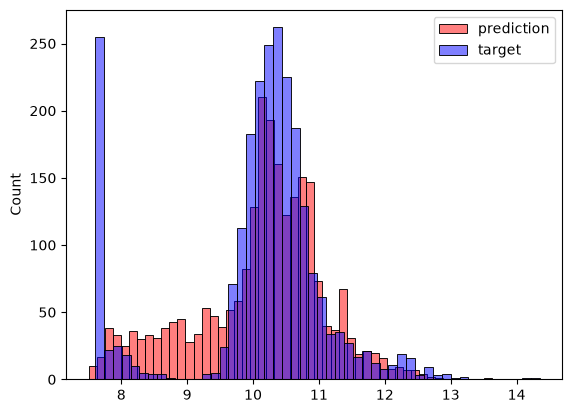

In [52]:
sns.histplot(y_pred, label='prediction', color='red', alpha=0.5, bins=50)
sns.histplot(y_val, label='target', color='blue',  alpha=0.5, bins=50)
plt.legend()

#2.12 Categorical variables


In [62]:
def prepare_X(df):
    df = df.copy()
    features = base.copy()

    df['age'] = 2017 - df.year
    features.append('age')

    for v in [2, 3, 4]:
        df['num_doors_%s' % v] = (df.number_of_doors == v).astype('int')
        features.append('num_doors_%s' % v)

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

df_train
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

df_train.make.value_counts().head()
car_df.make.value_counts().head()
makes = list(car_df.make.value_counts().head().index)
makes



def prepare_X(df):
    df = df.copy()
    features = base.copy()

    df['age'] = 2017 - df.year
    features.append('age')

    for v in [2, 3, 4]:
        df['num_doors_%s' % v] = (df.number_of_doors == v).astype('int')
        features.append('num_doors_%s' % v)

    for v in makes:
        df['make_%s' % v] = (df.make == v).astype('int')
        features.append('make_%s' % v)

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(0.5077439230324523)

In [67]:
categorical_variables = [
    'make', 'engine_fuel_type', 'transmission_type', 'driven_wheels',
    'market_category', 'vehicle_size', 'vehicle_style'
]

categories = {}

for c in categorical_variables:
    categories[c] = list(df_train[c].value_counts().head().index)



def prepare_X(df):
    df = df.copy()
    features = base.copy()

    df['age'] = 2017 - df.year
    features.append('age')

    for v in [2, 3, 4]:
        df['num_doors_%s' % v] = (df.number_of_doors == v).astype('int')
        features.append('num_doors_%s' % v)

    for c, values in categories.items():
        for v in values:
            df['%s_%s' % (c, v)] = (df[c] == v).astype('int')
            features.append('%s_%s' % (c, v))

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)
w0, w 

(np.float64(465087303477072.1),
 array([ 5.04204341e-02,  8.79010432e+00,  7.01819144e-01,  5.12909415e+00,
         5.60666519e-04,  1.94623652e+00, -2.33644193e+03, -2.32965887e+03,
        -2.32775009e+03,  5.46900815e-01, -5.52461286e-01,  1.82503263e+01,
        -3.04996073e+00,  1.11405185e+01, -5.24188209e+01, -4.48030685e+01,
        -4.47233917e+01, -1.86397045e+01, -1.37953843e+02, -3.10336756e+15,
        -3.10336756e+15, -3.10336756e+15, -3.10336756e+15, -3.10336756e+15,
         2.63828025e+15,  2.63828025e+15,  2.63828025e+15,  2.63828025e+15,
         2.86137909e+01,  5.80532147e+00, -6.00408043e-01,  3.78119153e+00,
         5.83625615e+01, -2.09987705e+01, -2.26899434e+01, -1.65546366e+01,
        -3.31855355e-02,  4.05238808e-02,  1.43085191e-01,  2.88144705e-01,
        -6.76988355e-02]))

#2.13. Regularization

Adding r value in the matrix diagonal to reduce the high value of RMSE before

In [68]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

X_train = prepare_X(df_train)
w0, w = train_linear_regression_reg(X_train, y_train, r=0.01)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(0.45287667440088447)

#2.14 Tuning the model

It is time to find the best r to make the model more acurate

In [69]:
for r in [0.0, 0.00001, 0.0001, 0.001, 0.1, 1, 10]:
    X_train = prepare_X(df_train)
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    X_val = prepare_X(df_val)
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred)

    print(r, w0, score)

0.0 465087303477072.1 56.0245975381616
1e-05 10.009247639485098 0.45286742822193793
0.0001 6.226529179221942 0.4528675185199478
0.001 6.263496173000115 0.4528683356793109
0.1 6.1412220342730555 0.45297176756378826
1 5.5216314026791595 0.4542219503366468
10 4.2610769393855055 0.4685524528733345


In [70]:
r = 0.001
X_train = prepare_X(df_train)
w0, w = train_linear_regression_reg(X_train, y_train, r=r)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
score = rmse(y_val, y_pred)
score

np.float64(0.4528683356793109)

#2.15 Using the model or training the final model

In [72]:
df_full_train = pd.concat([df_train, df_val])
df_full_train = df_full_train.reset_index(drop=True)
X_full_train = prepare_X(df_full_train)
y_full_train = np.concatenate([y_train, y_val])

w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)


In [73]:
X_test = prepare_X(df_test)
y_pred = w0 + X_test.dot(w)
score = rmse(y_test, y_pred)
score

np.float64(0.4604357451922703)

In [74]:
one_car = df_test.iloc[6].to_dict()
one_car

{'make': 'nissan',
 'model': 'sentra',
 'year': 2015,
 'engine_fuel_type': 'regular_unleaded',
 'engine_hp': 130.0,
 'engine_cylinders': 4.0,
 'transmission_type': 'automatic',
 'driven_wheels': 'front_wheel_drive',
 'number_of_doors': 4.0,
 'market_category': nan,
 'vehicle_size': 'midsize',
 'vehicle_style': 'sedan',
 'highway_mpg': 39,
 'city_mpg': 30,
 'popularity': 2009}

In [75]:
df_small = pd.DataFrame([one_car])
X_small = prepare_X(df_small)
y_pred = w0 + X_small.dot(w)
y_pred = y_pred[0]
y_pred

np.float64(9.906678922739122)

In [76]:
np.expm1(y_pred)

np.float64(20062.929360929455)